## Version 1 — Imports & config

6-class gesture recognition: No gesture, Swiping Left/Right, Turning Hand Clockwise/Counterclockwise, Zooming In With Two Fingers.

In [10]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from torch.utils.data import DataLoader, Dataset

ROOT = Path.cwd()
if not (ROOT / "final_data").exists() and (ROOT.parent / "final_data").exists():
    ROOT = ROOT.parent

FINAL_DATA_DIR = ROOT / "final_data"
SPLIT_FOLDERS = {
    "train": "train",
    "val": "validate",
    "test": "test",
}
SPLIT_CSVS = {
    "train": ROOT / "train.csv",
    "val": ROOT / "val.csv",
    "test": ROOT / "test.csv",
}

LABELS = [
    "No gesture",
    "Swiping Left",
    "Swiping Right",
    "Turning Hand Clockwise",
    "Turning Hand Counterclockwise",
    "Zooming In With Two Fingers",
]
LABEL_TO_IDX = {label: idx for idx, label in enumerate(LABELS)}
IDX_TO_LABEL = {idx: label for label, idx in LABEL_TO_IDX.items()}

VERSION_DIR = ROOT / "version1"
MODELS_DIR = VERSION_DIR / "models"

NUM_FRAMES = 37
INPUT_SIZE = 63
NUM_CLASSES = len(LABELS)
HIDDEN_SIZE = 128
NUM_LAYERS = 2
DROPOUT = 0.3
D_MODEL = 128
NHEAD = 4
DIM_FEEDFORWARD = 256
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
MAX_EPOCHS = 50
EARLY_STOP_PATIENCE = 7
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Device: {device}")
print(f"Classes ({NUM_CLASSES}): {LABELS}")

Device: mps
Classes (6): ['No gesture', 'Swiping Left', 'Swiping Right', 'Turning Hand Clockwise', 'Turning Hand Counterclockwise', 'Zooming In With Two Fingers']


## Dataset

In [2]:
class GestureDataset(Dataset):
    def __init__(self, split):
        folder = SPLIT_FOLDERS[split]
        data_dir = FINAL_DATA_DIR / folder
        metadata = pd.read_csv(SPLIT_CSVS[split])

        self.samples = []
        for _, row in metadata.iterrows():
            label = row["label"]
            if label not in LABEL_TO_IDX:
                continue

            video_id = int(row["video_id"])
            npy_path = data_dir / f"{video_id}.npy"
            if not npy_path.exists():
                continue

            self.samples.append((npy_path, LABEL_TO_IDX[label]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        npy_path, label = self.samples[idx]
        seq = np.load(npy_path).astype(np.float32)
        return torch.from_numpy(seq), torch.tensor(label, dtype=torch.long)


train_dataset = GestureDataset("train")
val_dataset = GestureDataset("val")
test_dataset = GestureDataset("test")

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)

print(f"Train: {len(train_dataset)}")
print(f"Val:   {len(val_dataset)}")
print(f"Test:  {len(test_dataset)}")

print("\nTrain label distribution:")
train_labels = pd.Series([IDX_TO_LABEL[label] for _, label in train_dataset.samples])
print(train_labels.value_counts())

Train: 12782
Val:   1616
Test:  1595

Train label distribution:
No gesture                       5749
Zooming In With Two Fingers      1646
Swiping Left                     1464
Swiping Right                    1447
Turning Hand Counterclockwise    1258
Turning Hand Clockwise           1218
Name: count, dtype: int64


## BiLSTM model

In [3]:
class GestureBiLSTM(nn.Module):
    def __init__(
        self,
        input_size=INPUT_SIZE,
        hidden_size=HIDDEN_SIZE,
        num_layers=NUM_LAYERS,
        num_classes=NUM_CLASSES,
        dropout=DROPOUT,
    ):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        _, (hidden, _) = self.lstm(x)
        forward_hidden = hidden[-2]
        backward_hidden = hidden[-1]
        last_hidden = torch.cat([forward_hidden, backward_hidden], dim=1)
        logits = self.classifier(self.dropout(last_hidden))
        return logits


model = GestureBiLSTM().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {num_params:,}")
print(model)

Trainable parameters: 594,438
GestureBiLSTM(
  (lstm): LSTM(63, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=256, out_features=6, bias=True)
)


## Training (early stopping on validation loss)

In [4]:
def run_epoch(loader, model, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    all_preds = []
    all_labels = []

    for sequences, labels in loader:
        sequences = sequences.to(device)
        labels = labels.to(device)

        if is_train:
            optimizer.zero_grad()

        logits = model(sequences)
        loss = criterion(logits, labels)

        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * labels.size(0)
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    return avg_loss, accuracy


history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss = float("inf")
best_state = None
epochs_without_improvement = 0

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss, train_acc = run_epoch(
        train_loader, model, criterion, optimizer
    )
    val_loss, val_acc = run_epoch(val_loader, model, criterion)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch:02d} | "
        f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
        f"val loss {val_loss:.4f} acc {val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= EARLY_STOP_PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

model.load_state_dict(best_state)
model.to(device)
print(f"Best validation loss: {best_val_loss:.4f}")

Epoch 01 | train loss 0.9936 acc 0.6594 | val loss 0.6684 acc 0.7908
Epoch 02 | train loss 0.5859 acc 0.8237 | val loss 0.6451 acc 0.7939
Epoch 03 | train loss 0.5266 acc 0.8393 | val loss 0.5487 acc 0.8329
Epoch 04 | train loss 0.4897 acc 0.8492 | val loss 0.5199 acc 0.8459
Epoch 05 | train loss 0.4672 acc 0.8584 | val loss 0.5212 acc 0.8459
Epoch 06 | train loss 0.4425 acc 0.8653 | val loss 0.4983 acc 0.8441
Epoch 07 | train loss 0.4416 acc 0.8661 | val loss 0.4744 acc 0.8496
Epoch 08 | train loss 0.4262 acc 0.8672 | val loss 0.4692 acc 0.8552
Epoch 10 | train loss 0.4044 acc 0.8740 | val loss 0.4750 acc 0.8564
Epoch 11 | train loss 0.3986 acc 0.8758 | val loss 0.4497 acc 0.8639
Epoch 12 | train loss 0.3827 acc 0.8827 | val loss 0.4849 acc 0.8583
Epoch 13 | train loss 0.3836 acc 0.8803 | val loss 0.4799 acc 0.8577
Epoch 14 | train loss 0.3659 acc 0.8877 | val loss 0.4266 acc 0.8688
Epoch 15 | train loss 0.3630 acc 0.8876 | val loss 0.4430 acc 0.8620
Epoch 16 | train loss 0.3457 acc 0

## Training curves

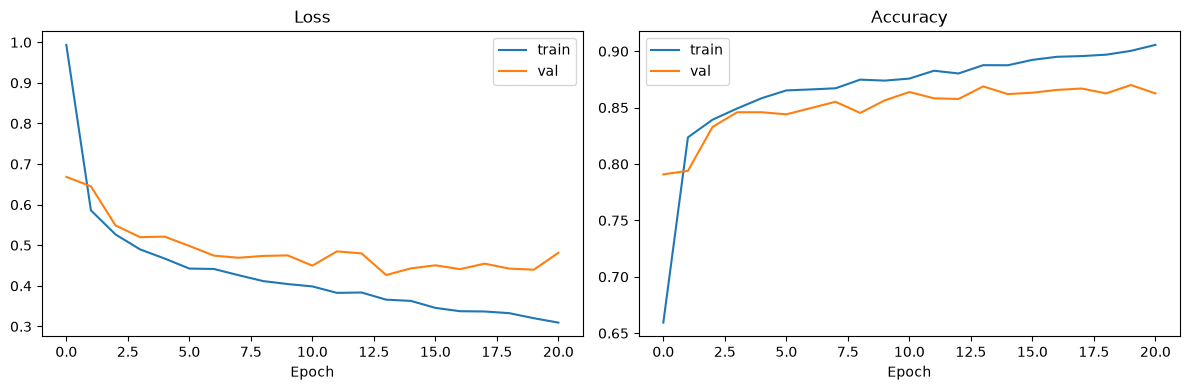

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## Test evaluation

Test loss: 0.3693
Test accuracy: 0.8809

Classification report:
                               precision    recall  f1-score   support

                   No gesture     0.8975    0.9499    0.9230       719
                 Swiping Left     0.8426    0.9071    0.8737       183
                Swiping Right     0.8953    0.8701    0.8825       177
       Turning Hand Clockwise     0.8016    0.6601    0.7240       153
Turning Hand Counterclockwise     0.8052    0.7898    0.7974       157
  Zooming In With Two Fingers     0.9568    0.8592    0.9054       206

                     accuracy                         0.8809      1595
                    macro avg     0.8665    0.8394    0.8510      1595
                 weighted avg     0.8803    0.8809    0.8791      1595



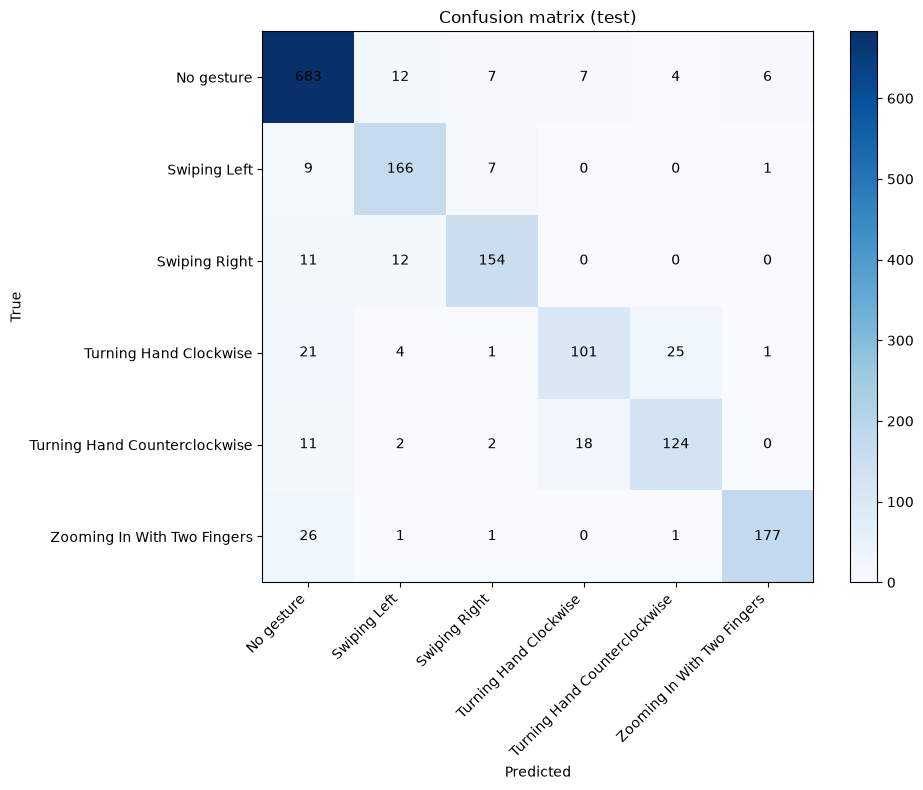

In [6]:
test_loss, test_acc = run_epoch(test_loader, model, criterion)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for sequences, labels in test_loader:
        sequences = sequences.to(device)
        logits = model(sequences)
        y_pred.extend(logits.argmax(dim=1).cpu().numpy())
        y_true.extend(labels.numpy())

print("\nClassification report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=LABELS,
        digits=4,
    )
)

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(NUM_CLASSES), LABELS, rotation=45, ha="right")
ax.set_yticks(range(NUM_CLASSES), LABELS)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix (test)")

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## Save model

In [8]:
if "MODELS_DIR" not in globals():
    from pathlib import Path

    _root = Path.cwd()
    if not (_root / "version1").exists() and (_root.parent / "version1").exists():
        _root = _root.parent
    MODELS_DIR = _root / "version1" / "models"

MODELS_DIR.mkdir(parents=True, exist_ok=True)

checkpoint = {
    "model_state_dict": model.state_dict(),
    "model_class": "GestureBiLSTM",
    "labels": LABELS,
    "label_to_idx": LABEL_TO_IDX,
    "hyperparameters": {
        "input_size": INPUT_SIZE,
        "hidden_size": HIDDEN_SIZE,
        "num_layers": NUM_LAYERS,
        "num_classes": NUM_CLASSES,
        "dropout": DROPOUT,
        "num_frames": NUM_FRAMES,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "seed": SEED,
    },
    "history": history,
    "best_val_loss": best_val_loss,
    "test_loss": test_loss,
    "test_accuracy": test_acc,
}

save_path = MODELS_DIR / "gesture_bilstm_v1.pt"
torch.save(checkpoint, save_path)
print(f"Saved model to {save_path.resolve()}")

Saved model to /Users/aryamanwade/Desktop/ml_projects/remote_desktop/remote-desktop/version1/models/gesture_bilstm_v1.pt


## Transformer model

In [11]:
class GestureTransformer(nn.Module):
    def __init__(
        self,
        input_size=INPUT_SIZE,
        d_model=D_MODEL,
        nhead=NHEAD,
        num_layers=NUM_LAYERS,
        dim_feedforward=DIM_FEEDFORWARD,
        num_classes=NUM_CLASSES,
        dropout=DROPOUT,
        max_len=NUM_FRAMES,
    ):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_embedding = nn.Parameter(torch.zeros(1, max_len, d_model))
        nn.init.trunc_normal_(self.pos_embedding, std=0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x):
        x = self.input_proj(x) + self.pos_embedding[:, : x.size(1), :]
        x = self.transformer(x)
        x = x.mean(dim=1)
        logits = self.classifier(self.dropout(x))
        return logits


model = GestureTransformer().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {num_params:,}")
print(model)

Trainable parameters: 278,662
GestureTransformer(
  (input_proj): Linear(in_features=63, out_features=128, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.3, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.3, inplace=False)
        (dropout2): Dropout(p=0.3, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=128, out_features=6, bias=True)
)


## Transformer training (early stopping on validation loss)

In [ ]:
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss = float("inf")
best_state = None
epochs_without_improvement = 0

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss, train_acc = run_epoch(
        train_loader, model, criterion, optimizer
    )
    val_loss, val_acc = run_epoch(val_loader, model, criterion)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch:02d} | "
        f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
        f"val loss {val_loss:.4f} acc {val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= EARLY_STOP_PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

model.load_state_dict(best_state)
model.to(device)
print(f"Best validation loss: {best_val_loss:.4f}")

Epoch 01 | train loss 0.8719 acc 0.6661 | val loss 0.6200 acc 0.8119
Epoch 02 | train loss 0.4963 acc 0.8474 | val loss 0.5235 acc 0.8428
Epoch 03 | train loss 0.4397 acc 0.8670 | val loss 0.4861 acc 0.8564
Epoch 04 | train loss 0.4254 acc 0.8726 | val loss 0.4947 acc 0.8441
Epoch 05 | train loss 0.4083 acc 0.8801 | val loss 0.4607 acc 0.8533
Epoch 06 | train loss 0.3918 acc 0.8816 | val loss 0.4326 acc 0.8700
Epoch 07 | train loss 0.3810 acc 0.8841 | val loss 0.4313 acc 0.8725
Epoch 08 | train loss 0.3642 acc 0.8906 | val loss 0.4161 acc 0.8707
Epoch 09 | train loss 0.3588 acc 0.8917 | val loss 0.5070 acc 0.8515
Epoch 10 | train loss 0.3567 acc 0.8917 | val loss 0.4244 acc 0.8694


## Transformer training curves

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Transformer Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_title("Transformer Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## Transformer test evaluation

In [ ]:
test_loss, test_acc = run_epoch(test_loader, model, criterion)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for sequences, labels in test_loader:
        sequences = sequences.to(device)
        logits = model(sequences)
        y_pred.extend(logits.argmax(dim=1).cpu().numpy())
        y_true.extend(labels.numpy())

print("\nClassification report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=LABELS,
        digits=4,
    )
)

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(NUM_CLASSES), LABELS, rotation=45, ha="right")
ax.set_yticks(range(NUM_CLASSES), LABELS)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Transformer confusion matrix (test)")

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## Save transformer model

In [ ]:
if "MODELS_DIR" not in globals():
    from pathlib import Path

    _root = Path.cwd()
    if not (_root / "version1").exists() and (_root.parent / "version1").exists():
        _root = _root.parent
    MODELS_DIR = _root / "version1" / "models"

MODELS_DIR.mkdir(parents=True, exist_ok=True)

checkpoint = {
    "model_state_dict": model.state_dict(),
    "model_class": "GestureTransformer",
    "labels": LABELS,
    "label_to_idx": LABEL_TO_IDX,
    "hyperparameters": {
        "input_size": INPUT_SIZE,
        "d_model": D_MODEL,
        "nhead": NHEAD,
        "num_layers": NUM_LAYERS,
        "dim_feedforward": DIM_FEEDFORWARD,
        "num_classes": NUM_CLASSES,
        "dropout": DROPOUT,
        "num_frames": NUM_FRAMES,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "seed": SEED,
    },
    "history": history,
    "best_val_loss": best_val_loss,
    "test_loss": test_loss,
    "test_accuracy": test_acc,
}

save_path = MODELS_DIR / "gesture_transformer_v1.pt"
torch.save(checkpoint, save_path)
print(f"Saved model to {save_path.resolve()}")

## LSTM model

In [ ]:
class GestureLSTM(nn.Module):
    def __init__(
        self,
        input_size=INPUT_SIZE,
        hidden_size=HIDDEN_SIZE,
        num_layers=NUM_LAYERS,
        num_classes=NUM_CLASSES,
        dropout=DROPOUT,
    ):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        _, (hidden, _) = self.lstm(x)
        last_hidden = hidden[-1]
        logits = self.classifier(self.dropout(last_hidden))
        return logits


model = GestureLSTM().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {num_params:,}")
print(model)

## LSTM training (early stopping on validation loss)

In [ ]:
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss = float("inf")
best_state = None
epochs_without_improvement = 0

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss, train_acc = run_epoch(
        train_loader, model, criterion, optimizer
    )
    val_loss, val_acc = run_epoch(val_loader, model, criterion)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch:02d} | "
        f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
        f"val loss {val_loss:.4f} acc {val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= EARLY_STOP_PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

model.load_state_dict(best_state)
model.to(device)
print(f"Best validation loss: {best_val_loss:.4f}")

## LSTM training curves

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("LSTM Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_title("LSTM Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## LSTM test evaluation

In [ ]:
test_loss, test_acc = run_epoch(test_loader, model, criterion)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for sequences, labels in test_loader:
        sequences = sequences.to(device)
        logits = model(sequences)
        y_pred.extend(logits.argmax(dim=1).cpu().numpy())
        y_true.extend(labels.numpy())

print("\nClassification report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=LABELS,
        digits=4,
    )
)

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(NUM_CLASSES), LABELS, rotation=45, ha="right")
ax.set_yticks(range(NUM_CLASSES), LABELS)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("LSTM confusion matrix (test)")

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## Save LSTM model

In [ ]:
if "MODELS_DIR" not in globals():
    from pathlib import Path

    _root = Path.cwd()
    if not (_root / "version1").exists() and (_root.parent / "version1").exists():
        _root = _root.parent
    MODELS_DIR = _root / "version1" / "models"

MODELS_DIR.mkdir(parents=True, exist_ok=True)

checkpoint = {
    "model_state_dict": model.state_dict(),
    "model_class": "GestureLSTM",
    "labels": LABELS,
    "label_to_idx": LABEL_TO_IDX,
    "hyperparameters": {
        "input_size": INPUT_SIZE,
        "hidden_size": HIDDEN_SIZE,
        "num_layers": NUM_LAYERS,
        "num_classes": NUM_CLASSES,
        "dropout": DROPOUT,
        "num_frames": NUM_FRAMES,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "seed": SEED,
    },
    "history": history,
    "best_val_loss": best_val_loss,
    "test_loss": test_loss,
    "test_accuracy": test_acc,
}

save_path = MODELS_DIR / "gesture_lstm_v1.pt"
torch.save(checkpoint, save_path)
print(f"Saved model to {save_path.resolve()}")